In [ ]:
import pandas as pd
import numpy as np

path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\raw\mahanadi_10k_2.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,133952.230146,2.249638e+06,0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,0,1714.680084,0.008238,30.779120,40,29
1,206784.841335,2.468185e+06,1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,0,1561.825018,0.006385,34.464436,40,30
2,459671.933327,2.241227e+06,2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,0,1767.091847,0.045409,36.737860,80,36
3,44328.737440,2.570529e+06,3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,0,1424.827479,0.024082,32.841915,10,31
4,60077.196604,2.480489e+06,4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,0,1839.188680,0.027140,32.228870,50,31


In [ ]:
df.info()

Index(['easting', 'northing', 'point_id', 'distance_to_river', 'aspect', 'dem',
       'flow_accumulation', 'twi', 'slope', 'flood', 'rainfall',
       'drainage_density', 'ext_rainfall', 'lulc', 'soil'],
      dtype='object')

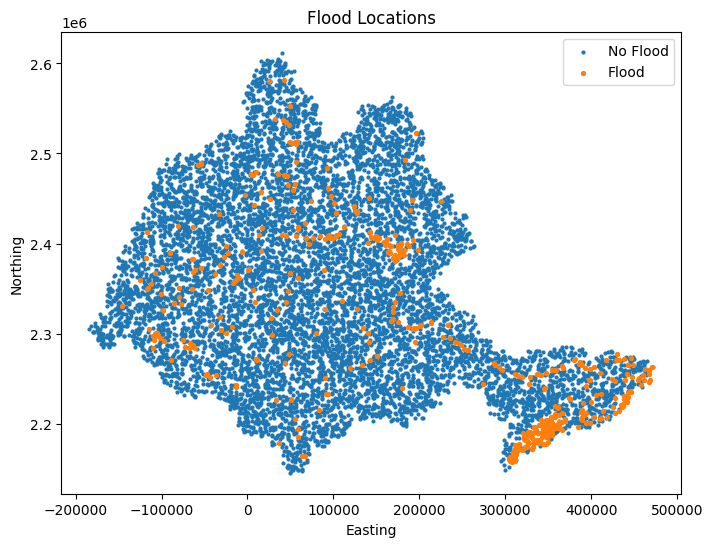

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

flood = df[df["flood"] == 1]
noflood = df[df["flood"] == 0]

plt.scatter(noflood["easting"], noflood["northing"], s=4, label="No Flood")
plt.scatter(flood["easting"], flood["northing"], s=8, label="Flood")

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood Locations")
plt.legend()

plt.show()

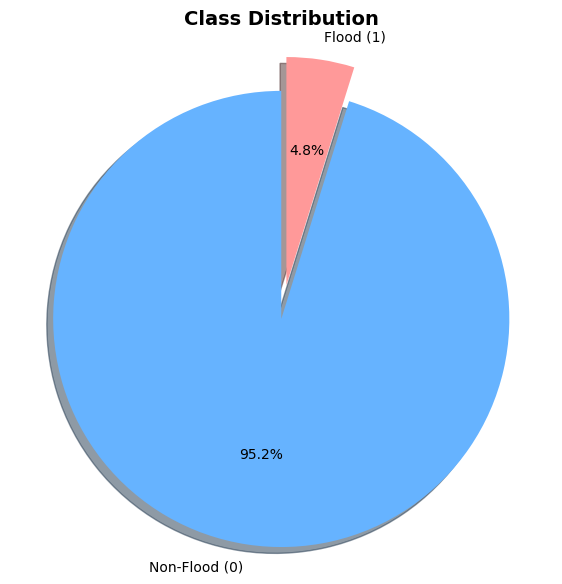

In [4]:
# Pie chart
fig, ax1 = plt.subplots(figsize=(7, 7))
colors = ['#66b3ff', '#ff9999']
flood_counts = df['flood'].value_counts().reindex([0, 1], fill_value=0)
ax1.pie(
    flood_counts,
    labels=['Non-Flood (0)', 'Flood (1)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.1),
    shadow=True
 )
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.axis('equal')  # Keep pie as a circle
plt.show()

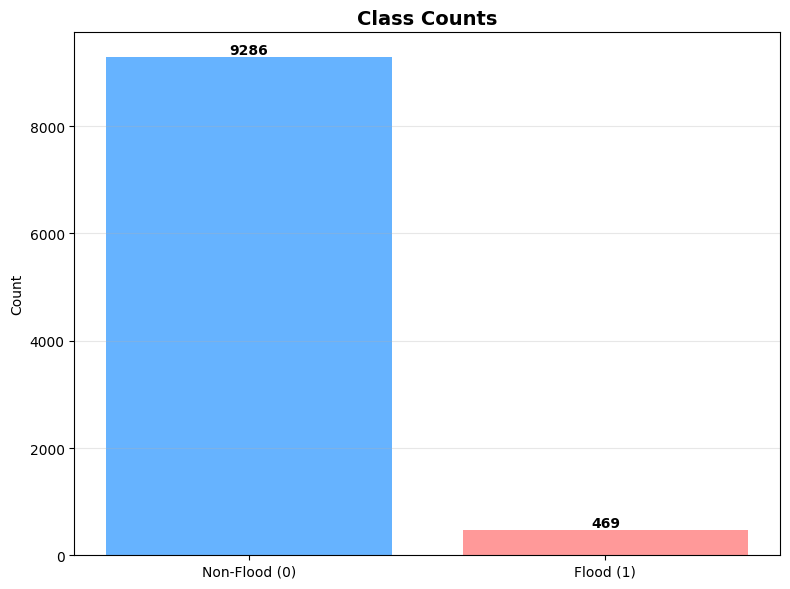

In [5]:
# Bar chart
fig, ax2 = plt.subplots(figsize=(8, 6))
colors = ['#66b3ff', '#ff9999']
flood_counts = df['flood'].value_counts().reindex([0, 1], fill_value=0)
bars = ax2.bar(['Non-Flood (0)', 'Flood (1)'], flood_counts.values, color=colors)
ax2.set_title('Class Counts', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, flood_counts.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, height + 5,
             f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Observation: Class Distribution

The pie and bar charts clearly show the distribution of **Flood (1)** and **Non-Flood (0)** samples in the dataset.

This check is important before training because class balance directly affects model behavior and evaluation reliability.

From the visual pattern, the dataset appears suitable for proceeding, while still keeping class distribution in mind during model validation and performance reporting.

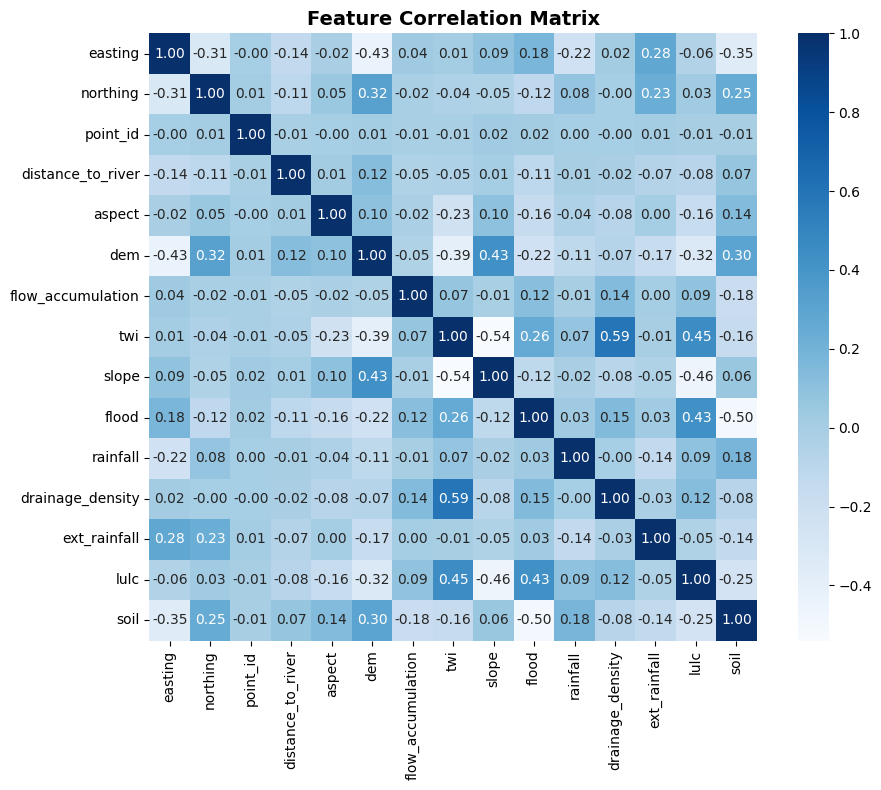

In [6]:
# Correlation between numeric features
import seaborn as sns

corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True,
    cbar=True
 )
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

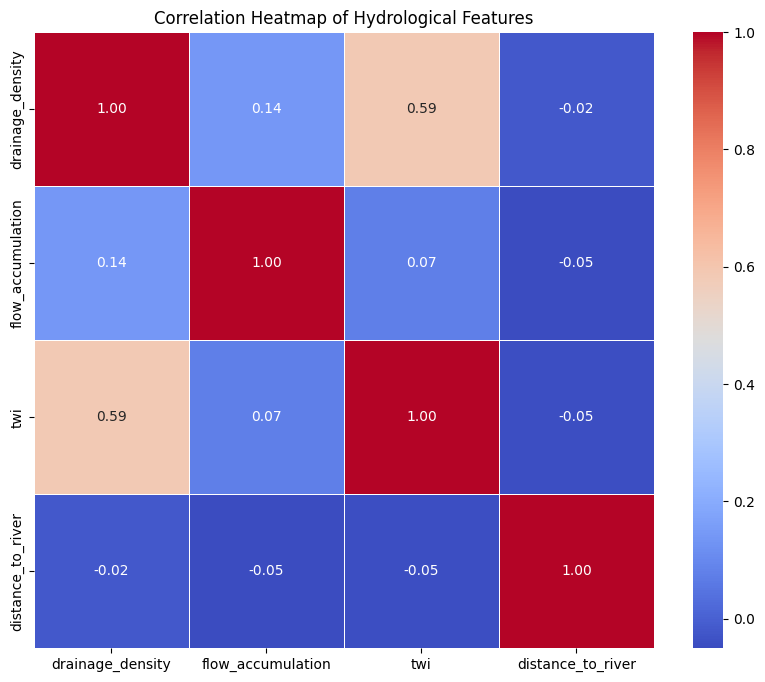

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features to correlate
corr_features = ['drainage_density', 'flow_accumulation', 'twi', 'distance_to_river']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Hydrological Features')
plt.show()

## Observation: Feature Correlation Analysis

The correlation analysis indicates that the predictor relationships are within acceptable modeling limits. No severe multicollinearity is observed among independent variables; the highest feature-to-feature correlation is between **Topographic Wetness Index (TWI)** and **drainage density** ($r = 0.59$), which is below the commonly used threshold of $0.80$.

Strong associations with the target variable (**flood**) are also evident, especially for:
- **soil** ($r = -0.50$)
- **lulc** ($r = 0.43$)

These relationships suggest meaningful predictive signal for model learning. Based on this assessment, no feature elimination or dimensionality reduction is required at this stage, and the dataset is ready for the model training phase.